<a href="https://colab.research.google.com/github/mserhat1/NMA_Project/blob/main/testing_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IF YOU WANT TO TEST, RUN THE FIRST THREE CELLS AND GO TO THE END OF THE NOTEBOOK WITH THE HEADLINE "TRAINING AND TEST"

In [ ]:
!git clone https://github.com/mserhat1/NMA_Project.git
import sys
sys.path.append('/content/NMA_Project')

In [ ]:
%cd NMA_Project
!pip install -r requirements.txt

In [3]:
from functions.data import get_datafile

# sbj 6 has visual cortex electrodes

sbj = 10
session = 3

nwbfile = get_datafile(sbj=sbj, session=session)

Extract spatial data

In [14]:
#from functions.data import extract_spatial_data

spatial_data = extract_spatial_data(nwbfile, time_window=(55000, 56000))

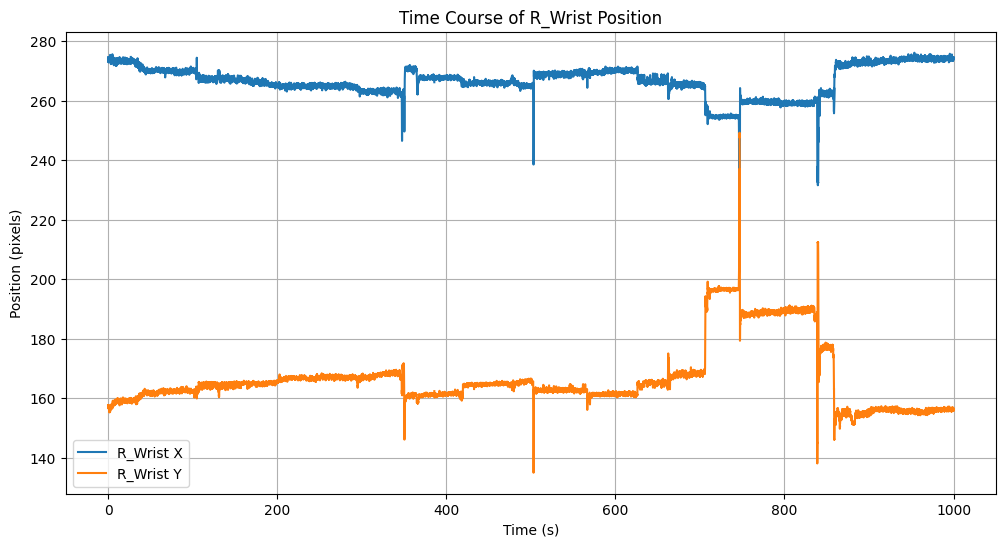

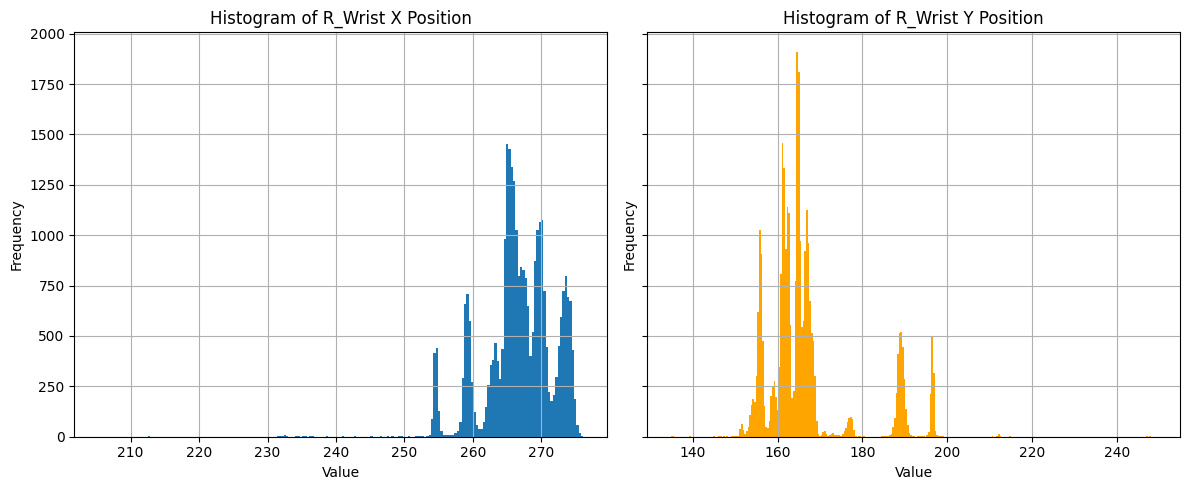

In [15]:
from functions.plotting_new import plot_spatial_data

plot_spatial_data(spatial_data, keypoints=['R_Wrist'])

Extract neural data

In [16]:
from functions.data import extract_neural_data

# specify parameters
channel = 'all'
#train_window = (0, 43200)
#test_window = (43200, 86400)

ecog_data = extract_neural_data(nwbfile, channel=channel, time_window=(55000, 56000))

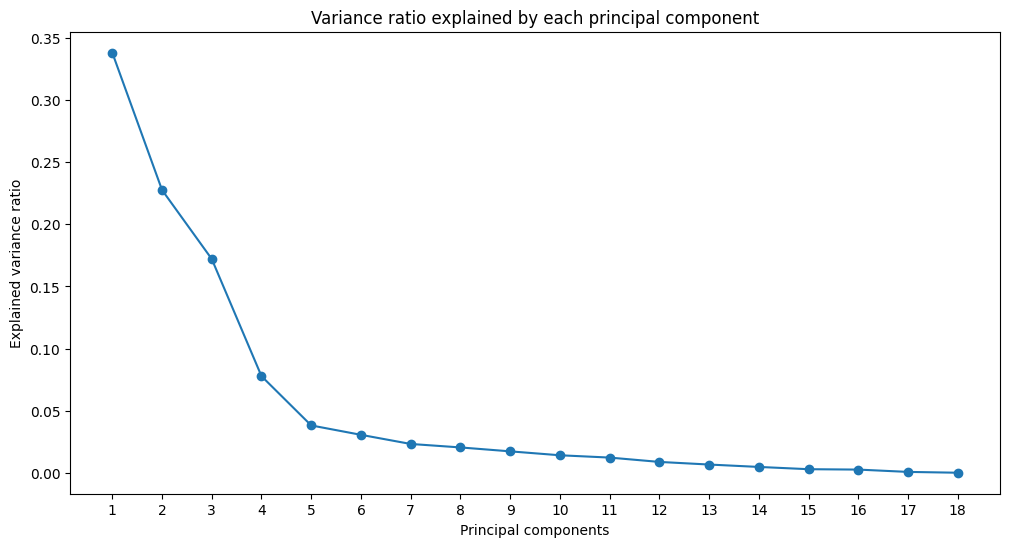

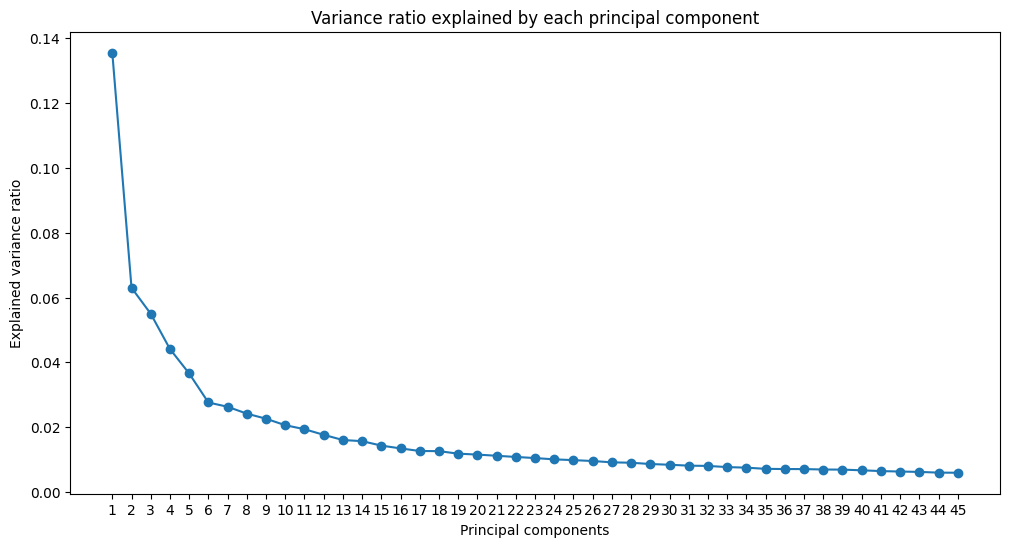

In [18]:
from functions.analysis import keypoints_pca, ecog_pca

spatial_pca = keypoints_pca(spatial_data, interp_reference=ecog_data['signal'], plot=True)
neural_pca = ecog_pca(ecog_data, time_window=(55000, 56500), n_components=0.80, plot=True)

In [11]:
# Seems like 4 PC's is a good choice in this case.
chosen_pcs = 4

kp_data = spatial_pca['kp_data']
pcs = spatial_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, kp_data.shape)
projected_spatial = kp_data @ top_pcs.T

print(projected_spatial.shape) # (n_samples, n_components)

(4, 18) (500000, 18)
(500000, 4)


In [12]:
chosen_pcs = 12
neural_data = neural_pca['kp_data']
pcs = neural_pca['components'] # (n_components, n_features)
top_pcs = pcs[:chosen_pcs, :]

print(top_pcs.shape, neural_data.shape)
projected_neural = neural_data @ top_pcs.T

print(projected_neural.shape) # (n_samples, n_components)

(12, 126) (500000, 126)
(500000, 12)


In [13]:
from functions.model import RRR

A, C = RRR(projected_spatial, projected_neural)

In [14]:
print(A.shape, C.shape)

(4, 4) (12, 4)


TRAINING AND TEST

(126, 15000)


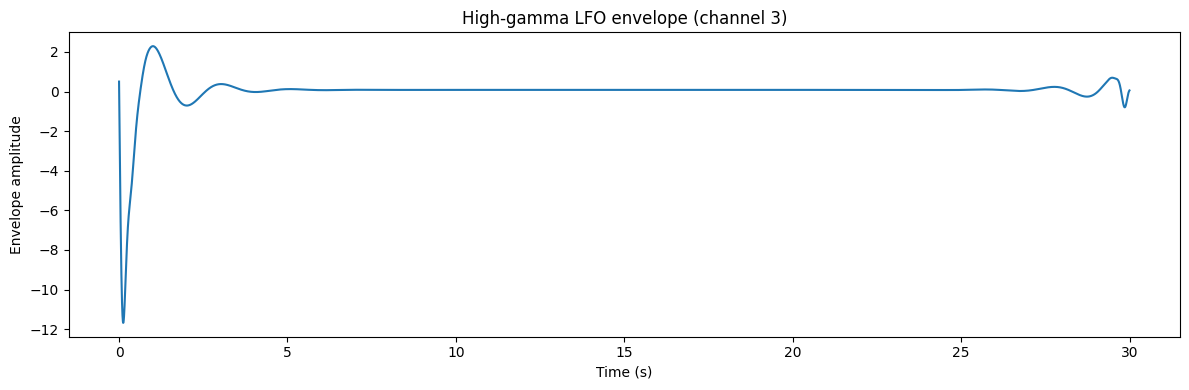

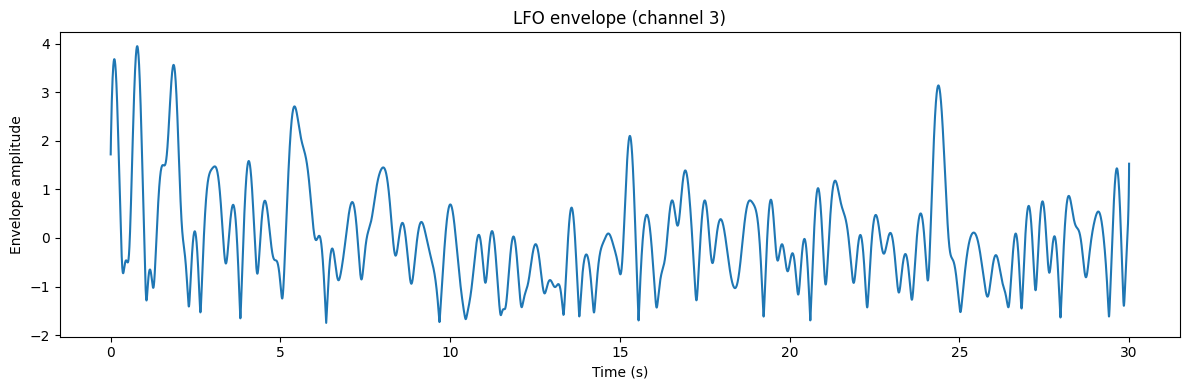

In [94]:
from functions.wenyu_function import extract_gammaH_LFO, extract_LFO_envelope, plot_gamma_lfo, plot_lfo_envelope, plot_power_spectrum

gamma_lfo = extract_gammaH_LFO(ecog_train, time_window='all')
print(gamma_lfo.shape)

lfo_envelope = extract_LFO_envelope(ecog_train, time_window='all', zscore=True)

ch_to_plot = 3

plot_gamma_lfo(gamma_lfo, ecog_train['sampling_rate'], channel=ch_to_plot)

plot_lfo_envelope(lfo_envelope, ecog_train['sampling_rate'], channel=ch_to_plot)

In [119]:
# you can adjust windows etc., using the entire 86400 sample window is not advisable, takes too long.

from functions.data import extract_spatial_data, extract_neural_data
from functions.analysis import keypoints_pca, ecog_pca, project_onto_pcs

train_window = (55000, 55030)
test_window = (55030, 55060)
channel = [7, 9]

spatial_train = extract_spatial_data(nwbfile, train_window)
spatial_test = extract_spatial_data(nwbfile, test_window)
ecog_train = extract_neural_data(nwbfile, channel=channel, time_window=train_window)
ecog_test = extract_neural_data(nwbfile, channel=channel, time_window=test_window)

In [108]:
import numpy as np
from scipy.signal import butter, filtfilt

def bandpass_filter(ecog_data, lowcut=0.5, highcut=4.0, order=4):
    """
    Apply a bandpass filter to a multi-channel signal.

    Parameters:
        signal (np.ndarray): Input array of shape (n_samples, n_channels).
        fs (float): Sampling rate in Hz.
        lowcut (float): Low cutoff frequency in Hz.
        highcut (float): High cutoff frequency in Hz.
        order (int): Order of the Butterworth filter.

    Returns:
        np.ndarray: Bandpass-filtered signal of the same shape.
    """
    signal = ecog_data['signal']
    signal = signal.astype(np.float64)
    fs = ecog_data['sampling_rate']

    if signal.ndim != 2:
        raise ValueError("Signal must be a 2D array (n_samples, n_channels)")

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype='band')

    # Apply filter channel-wise
    filtered = np.empty_like(signal)
    for i in range(signal.shape[1]):
        filtered[:, i] = filtfilt(b, a, signal[:, i], axis=0)

    filtered_ecog = ecog_data.copy()
    filtered_ecog['signal'] = filtered.astype(np.float64)

    return filtered_ecog

In [120]:
# Wenyu's functions
from functions.wenyu_function import extract_gammaH_LFO, extract_LFO_envelope, plot_gamma_lfo, plot_lfo_envelope, plot_power_spectrum

filtered_ecog_train = ecog_train.copy()
filtered_ecog_test = ecog_test.copy()

filtered_ecog_train['signal'] = extract_gammaH_LFO(ecog_train, time_window='all').T
filtered_ecog_test['signal'] = extract_gammaH_LFO(ecog_test, time_window='all').T

In [131]:
# Regular bandpass filter

filtered_ecog_train = bandpass_filter(ecog_train, lowcut=0.1, highcut=1, order=2)
filtered_ecog_test = bandpass_filter(ecog_test, lowcut=0.1, highcut=1, order=2)

In [132]:
from functions.analysis import keypoints_pca, ecog_pca
from functions.analysis import time_interpolate

spatial_pca_train = keypoints_pca(spatial_train, interp_reference=ecog_train['signal'], plot=False)
neural_pca_train = ecog_pca(filtered_ecog_train, time_window=train_window, n_components=0.80, plot=False)

spatial_pca_test = keypoints_pca(spatial_test, interp_reference=ecog_test['signal'], plot=False)
neural_pca_test = ecog_pca(filtered_ecog_test, time_window=test_window, n_components=0.80, plot=False)

In [133]:
proj_spatial_train = project_onto_pcs(spatial_pca_train, n_pcs=6)
proj_neural_train = project_onto_pcs(neural_pca_train, n_pcs=2)

proj_spatial_test = project_onto_pcs(spatial_pca_test, n_pcs=6)
proj_neural_test = project_onto_pcs(neural_pca_test, n_pcs=2)

In [134]:
from functions.model import RRR

A, C = RRR(proj_spatial_train, proj_neural_train)

In [135]:
estimated_neural_test = proj_spatial_test @ A @ C.T

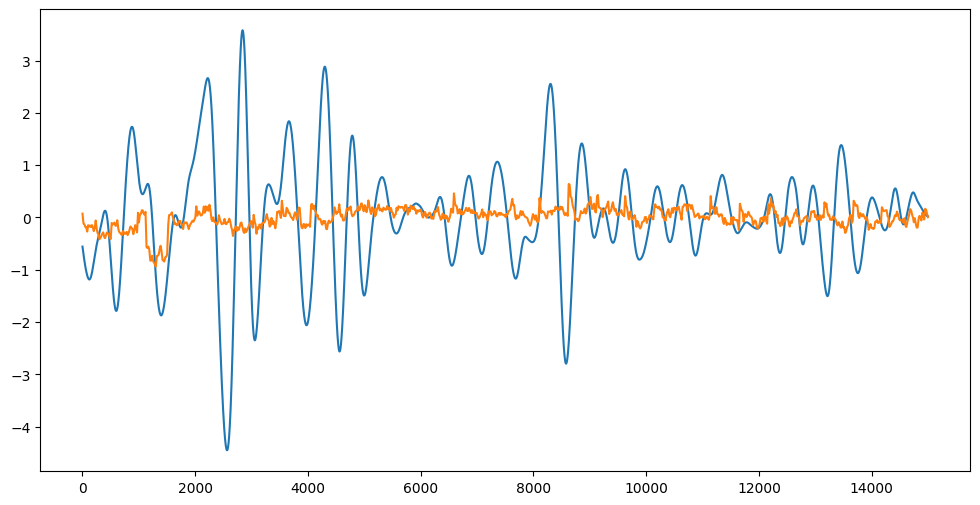

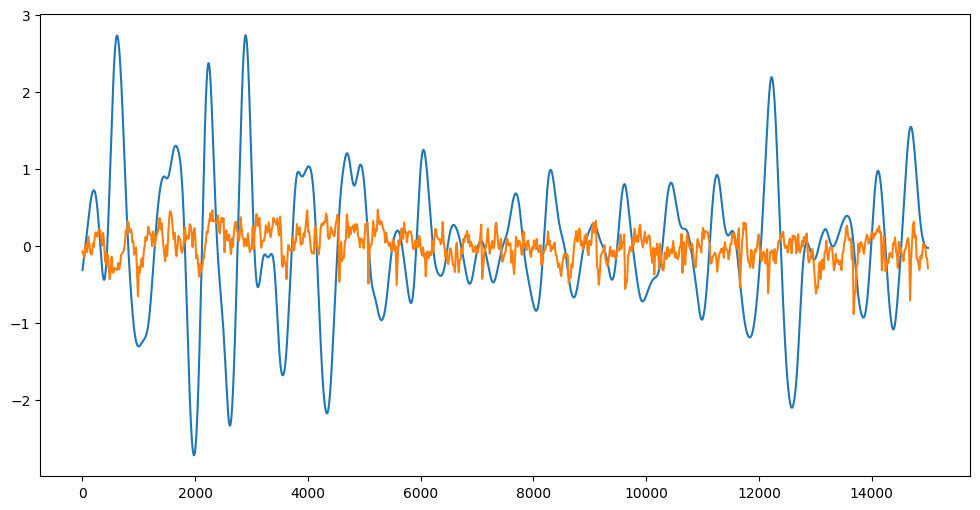

In [136]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(proj_neural_test.shape[1]):
  plt.figure(figsize=(12, 6))
  plt.plot(proj_neural_test[:, i], label='True')
  plt.plot(estimated_neural_test[:, i], label='Estimated')